# Computer Exercise 15.12 — Problem 3
## 신경망 파라미터화 규모 이행: 선형 함수근사 위 QR-DQN · IQN · Rainbow-lite

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.12
> **날짜**: 2026-07-27
> **언어**: 한국어 본문 + 영문 라벨

## 1. 문제 (원문)

> **Scaling QR-DQN / IQN / Rainbow-lite through linear function approximation.** Problems 1–2 established, on a 4×4 tabular GridWorld, that (a) QR-DQN removes the C51 support residual, (b) IQN attains equivalent mean accuracy with fewer stored parameters and free-form τ queries. Days 76–78 further established that on slippery environments n-step bootstrap revives its benefit. The natural next question is: *do these tabular observations survive when we abandon the (s, a)-indexed lookup and force a shared linear head over state features?* Concretely: replace tabular $Q(s, a)$ (or $\theta(s, a, k)$, or $w(s, a) \in \mathbb R^D$) with $Q(s, a) = \phi(s)^\top W(a)$ for a modest hand-crafted feature $\phi$, keep everything else identical, and run four conditions on a $6\times 6$ *slippery* GridWorld with $p_\text{slip}=0.2$ and $\sigma_R = 0.5$: (i) linear scalar Q (baseline), (ii) linear QR-DQN, (iii) linear IQN, (iv) linear "Rainbow-lite" = QR-DQN + n-step $= 3$. Measure tail-50 return and Q-mean $\ell_\infty$ error vs the true $Q^\star$ computed by value iteration on the slippery dynamics.

### 한국어 풀이용 정리

- 환경: **6×6 slippery GridWorld**, $p_\text{slip}=0.2$, 잡음 보상 $r=-1+\mathcal N(0, 0.5^2)$, 목표 도달 시 종료.
- 특징벡터: row one-hot (6) + col one-hot (6) + bias (1) = **$D_\phi=13$** 특징. tabular 가 아니라 각 성분이 여러 상태에 공유되는 진짜 선형 근사기.
- 4 조건: **linear scalar Q**, **linear QR-DQN (K=21)**, **linear IQN (D=12)**, **linear Rainbow-lite (QR-DQN + n=3)**.
- 학습: 8 시드 × 120 에피소드.
- 측정: tail-50 리턴, tail $\|Q_\text{mean} - Q^\star\|_\infty$, 학습곡선.
- 목적: (i) tabular 관찰이 선형 근사기 규모에서도 살아남는지, (ii) slippery 환경에서 n-step 이 재활성화되는지 (Day 77 예측), (iii) IQN 이 여전히 QR-DQN 과 등가 성능을 유지하는지.

## 2. 수학적 배경

**Slippery GridWorld 동역학.** 행동 $a$ 를 선택하면 확률 $1-p_\text{slip}$ 으로 의도한 방향, 확률 $p_\text{slip}/2$ 씩 좌우 90° 회전 방향으로 이동. 이 확률 전이가 Bellman 표적 $r + \gamma\, V(s')$ 에 실질적 분산을 만들어 **n-step 부트스트랩의 편향-분산 트레이드오프** 를 살린다 (Day 77 관찰).

**선형 QR-DQN.** 각 action $a$ 와 quantile index $k$ 에 대해 파라미터 $W_a \in \mathbb R^{D_\phi \times K}$:
$$\theta_k(s, a) = \phi(s)^\top W_a[:, k], \qquad Q(s, a) = \frac{1}{K}\sum_k \theta_k(s, a) = \phi(s)^\top \bar W_a.$$
Quantile Huber gradient (Problem 1) 를 features 로 back-propagate:
$$\frac{\partial\mathcal L}{\partial W_a[:, k]} = g_k \cdot \phi(s),\qquad g_k = -\frac{1}{K}\sum_j w_{kj}(u) \cdot L'_\kappa(u_{kj}).$$

**선형 IQN.** 각 action $a$ 에 파라미터 $W_a \in \mathbb R^{D_\phi \times D}$, $b_a \in \mathbb R^{D_\phi}$ (mean channel):
$$Z(s, a; \tau) = \phi(s)^\top W_a \phi_\tau(\tau) + \phi(s)^\top b_a.$$
분산-평균 분리는 tabular 와 동일 원리 ($\int_0^1 \cos(i\pi\tau)d\tau = 0$).

**n-step 부트스트랩.**
$$G_{t:t+n} = \sum_{k=0}^{n-1} \gamma^k r_{t+k+1} + \gamma^n\, \theta_j(s_{t+n}, a^\star_{t+n}),$$
편향 $\sim \gamma^n$, 분산 $\sim \sigma^2(1-\gamma^{2n})/(1-\gamma^2)$. Slippery 환경 → $\sigma^2$ 실효값이 크다 → 결정적 환경 대비 스윗스팟이 $n=1$ 에서 $n=3$ 방향으로 이동 (Day 77 예측).

$$\boxed{\; \text{tabular → linear 규모 이행: 표현력 공유가 sample efficiency 를 올리는지, 병리는 없는지 관찰.}\;}$$

## 3. 풀이 흐름

1. 6×6 slippery GridWorld 정의 ($p_\text{slip}=0.2$, $\sigma_R = 0.5$).
2. 참값 $Q^\star$: slippery 동역학에 대한 value iteration (기대 보상 $-1$, 확률 전이).
3. 특징: $\phi(s) = [\text{row\_onehot}, \text{col\_onehot}, 1]$ ($D_\phi = 13$).
4. **Linear scalar Q**: SGD, $\alpha = 0.05$, $\varepsilon = 0.1$.
5. **Linear QR-DQN**: $K=21$, quantile Huber grad, $\alpha = 0.05$.
6. **Linear IQN**: $D=12$ cosine, $M_\text{on}=M_\text{tar}=6$, $\alpha=0.02$.
7. **Linear Rainbow-lite**: linear QR-DQN + n-step $n=3$ 부트스트랩 (버퍼로 마지막 $n$ 전이 유지).
8. 8 시드 × 120 에피소드.
9. 요약표 + 3 패널 시각화.

In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ── 환경: 6x6 slippery GridWorld ──────────────────────────────────
N = 6
GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0),(0,1),(1,0),(0,-1)])
NA = 4; NS = N*N; GAMMA = 0.99; SIGMA_R = 0.5; P_SLIP = 0.2

def s_idx(rc): return rc[0]*N + rc[1]

def step(rc, a, rng):
    # slippery: with prob P_SLIP/2 rotate left, P_SLIP/2 rotate right
    u = rng.random()
    if u < P_SLIP/2:
        aa = (a - 1) % NA
    elif u < P_SLIP:
        aa = (a + 1) % NA
    else:
        aa = a
    dr, dc = ACTIONS[aa]
    nr = max(0, min(N-1, rc[0]+dr))
    nc = max(0, min(N-1, rc[1]+dc))
    ns = (nr, nc); done = (ns == GOAL)
    r = -1.0 + rng.normal(0.0, SIGMA_R)
    return ns, r, done

def value_iteration():
    # exact slippery Bellman
    Q = np.zeros((NS, NA))
    def next_states(r, c, a):
        neigh = []
        for da, p in [((a-1)%NA, P_SLIP/2), (a, 1-P_SLIP), ((a+1)%NA, P_SLIP/2)]:
            dr, dc = ACTIONS[da]
            nr = max(0, min(N-1, r+dr))
            nc = max(0, min(N-1, c+dc))
            neigh.append((nr, nc, p))
        return neigh
    for _ in range(2000):
        Qn = np.zeros_like(Q)
        for r in range(N):
            for c in range(N):
                if (r, c) == GOAL:
                    Qn[s_idx((r,c))] = 0.0; continue
                for a in range(NA):
                    val = 0.0
                    for nr, nc, p in next_states(r, c, a):
                        ns = (nr, nc)
                        if ns == GOAL:
                            val += p * (-1.0)
                        else:
                            val += p * (-1.0 + GAMMA * Q[s_idx(ns)].max())
                    Qn[s_idx((r,c)), a] = val
        if np.max(np.abs(Qn - Q)) < 1e-8: break
        Q = Qn
    return Q

Q_star = value_iteration()
V_star = Q_star[s_idx((0,0))].max()
print(f"V* on slippery 6x6 = {V_star:.4f}")

# features
def phi(rc):
    row = np.zeros(N); row[rc[0]] = 1.0
    col = np.zeros(N); col[rc[1]] = 1.0
    return np.concatenate([row, col, [1.0]])

D_PHI = 2*N + 1
Phi = np.stack([phi((r, c)) for r in range(N) for c in range(N)])   # (NS, D_PHI)


/tmp/mplcache is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-_jk4a9vs because there was an issue with the default path (/tmp/mplcache); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


V* on slippery 6x6 = -11.5336


In [2]:

# ── (1) Linear scalar Q -----------------------------------------------
def run_lin_scalar(seed, n_ep=120, alpha=0.05, eps=0.1):
    rng = np.random.default_rng(seed)
    W = np.zeros((NA, D_PHI))     # W[a] gives Q(s, a) via phi(s) . W[a]
    returns = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for ep in range(n_ep):
        s = (0, 0); G = 0.0
        for _ in range(400):
            f = phi(s)
            Qs = W @ f
            a = rng.integers(NA) if rng.random() < eps else int(Qs.argmax())
            ns, r, done = step(s, a, rng)
            if done:
                target = r
            else:
                Qn = W @ phi(ns)
                target = r + GAMMA * Qn.max()
            td = target - Qs[a]
            W[a] += alpha * td * f
            G += r; s = ns
            if done: break
        returns[ep] = G
        Q_all = Phi @ W.T             # (NS, NA)
        q_err[ep] = np.max(np.abs(Q_all - Q_star))
    return returns, q_err

# ── (2) Linear QR-DQN -------------------------------------------------
K = 21
TAU_QR = (np.arange(K) + 0.5) / K
KAPPA = 1.0

def run_lin_qrdqn(seed, n_ep=120, alpha=0.05, eps=0.1, n_step=1):
    rng = np.random.default_rng(seed)
    W = np.zeros((NA, D_PHI, K))     # W[a][:, k]
    def q_all():
        return np.einsum('sd,adk->sak', Phi, W).mean(-1)   # (NS, NA)
    returns = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for ep in range(n_ep):
        s = (0, 0); G = 0.0
        buf = []   # n-step buffer: list of (phi, a, r)
        for _ in range(400):
            f = phi(s)
            theta_s = np.einsum('adk,d->ak', W, f)          # (NA, K)
            Qs = theta_s.mean(-1)
            a = rng.integers(NA) if rng.random() < eps else int(Qs.argmax())
            ns, r, done = step(s, a, rng)
            buf.append((f, a, r))
            if len(buf) >= n_step or done:
                # form n-step return target at buf[0]
                f0, a0, _ = buf[0]
                G_n = 0.0
                for k, (_, _, rk) in enumerate(buf[:n_step]):
                    G_n += (GAMMA ** k) * rk
                if done:
                    target = np.full(K, G_n)
                else:
                    f_next = phi(ns)
                    theta_next = np.einsum('adk,d->ak', W, f_next)   # (NA, K)
                    a_star = int(theta_next.mean(-1).argmax())
                    target = G_n + (GAMMA ** len(buf[:n_step])) * theta_next[a_star]  # (K,)
                # gradient on theta(f0, a0)
                theta_cur = np.einsum('dk,d->k', W[a0], f0)         # (K,)
                u = (target[None, :] - theta_cur[:, None])          # (K,K); rows k, cols j
                w_ = np.where(u < 0, 1.0 - TAU_QR[:, None], TAU_QR[:, None])
                dL = np.where(np.abs(u) <= KAPPA, u, KAPPA * np.sign(u))
                grad_theta = -(w_ * dL).mean(axis=1)               # (K,)
                # W[a0] : (D, K), dtheta/dW = f0 outer e_k → dL/dW = f0[:, None] * grad_theta[None, :]
                W[a0] -= alpha * (f0[:, None] * grad_theta[None, :])
                buf.pop(0)
            G += r; s = ns
            if done:
                # flush remaining buffer
                while buf:
                    f0, a0, _ = buf[0]
                    G_n = 0.0
                    for k, (_, _, rk) in enumerate(buf):
                        G_n += (GAMMA ** k) * rk
                    target = np.full(K, G_n)
                    theta_cur = np.einsum('dk,d->k', W[a0], f0)
                    u = (target[None, :] - theta_cur[:, None])
                    w_ = np.where(u < 0, 1.0 - TAU_QR[:, None], TAU_QR[:, None])
                    dL = np.where(np.abs(u) <= KAPPA, u, KAPPA * np.sign(u))
                    grad_theta = -(w_ * dL).mean(axis=1)
                    W[a0] -= alpha * (f0[:, None] * grad_theta[None, :])
                    buf.pop(0)
                break
        returns[ep] = G
        q_err[ep] = np.max(np.abs(q_all() - Q_star))
    return returns, q_err

# ── (3) Linear IQN ----------------------------------------------------
D_IQN = 12
def cosine_embed(tau):
    i = np.arange(1, D_IQN+1)
    return np.cos(np.pi * i[None, :] * tau[:, None])

def run_lin_iqn(seed, n_ep=120, alpha=0.02, eps=0.1, M_on=6, M_tar=6):
    rng = np.random.default_rng(seed)
    W = np.zeros((NA, D_PHI, D_IQN))   # cosine head
    b = np.zeros((NA, D_PHI))          # mean head (like scalar Q linear)
    def qmean_state(f):
        return b @ f   # (NA,)
    returns = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for ep in range(n_ep):
        s = (0, 0); G = 0.0
        for _ in range(400):
            f = phi(s)
            Qs = qmean_state(f)
            a = rng.integers(NA) if rng.random() < eps else int(Qs.argmax())
            ns, r, done = step(s, a, rng)

            tau_on = rng.uniform(0.0, 1.0, size=M_on)
            phi_on = cosine_embed(tau_on)             # (M_on, D_IQN)
            # z_on = phi(s).T W[a] phi_on.T + phi(s).T b[a]   → scalar per k
            z_on = phi_on @ (W[a].T @ f) + (b[a] @ f)  # (M_on,)

            if done:
                z_tar = np.full(M_tar, r)
            else:
                fn = phi(ns)
                a_star = int((b @ fn).argmax())
                tau_tar = rng.uniform(0.0, 1.0, size=M_tar)
                phi_tar = cosine_embed(tau_tar)
                z_tar = r + GAMMA * (phi_tar @ (W[a_star].T @ fn) + (b[a_star] @ fn))

            u = z_tar[None, :] - z_on[:, None]        # (M_on, M_tar)
            weight = np.where(u < 0, 1.0 - tau_on[:, None], tau_on[:, None])
            dL = np.where(np.abs(u) <= KAPPA, u, KAPPA * np.sign(u))
            g_zk = -(weight * dL).mean(axis=1)        # (M_on,)
            # grad wrt W[a] : d z_on[k]/dW[a] = f outer phi_on[k]
            gW = np.zeros((D_PHI, D_IQN))
            for k in range(M_on):
                gW += g_zk[k] * (f[:, None] * phi_on[k, None, :])
            gW /= M_on
            gb = f * g_zk.mean()
            W[a] -= alpha * gW
            b[a] -= alpha * gb

            G += r; s = ns
            if done: break
        returns[ep] = G
        # Q_mean over all states via b matrix
        Q_all = Phi @ b.T
        q_err[ep] = np.max(np.abs(Q_all - Q_star))
    return returns, q_err

# ── (4) Linear Rainbow-lite = linear QR-DQN + n-step=3 -----------------
def run_lin_rainbow(seed, n_ep=120):
    return run_lin_qrdqn(seed, n_ep, n_step=3)


In [3]:

N_SEEDS = 8; N_EP = 120
SEEDS = np.arange(9300, 9300 + N_SEEDS)

configs = [
    ("linear scalar Q",       run_lin_scalar),
    ("linear QR-DQN",         run_lin_qrdqn),
    ("linear IQN",            run_lin_iqn),
    ("linear Rainbow-lite (QR+n=3)", run_lin_rainbow),
]

results = {}
for name, fn in configs:
    R = np.zeros((N_SEEDS, N_EP)); E = np.zeros((N_SEEDS, N_EP))
    for i, s in enumerate(SEEDS):
        R[i], E[i] = fn(int(s), N_EP)
    results[name] = (R, E)
    print(f"{name} done, tail return = {R[:,-50:].mean():.3f}")

TAIL = 50
rows = []
for name, (R, E) in results.items():
    rows.append(dict(
        method=name,
        tail_return=float(R[:, -TAIL:].mean()),
        tail_return_std=float(R[:, -TAIL:].mean(1).std()),
        tail_q_err=float(E[:, -TAIL:].mean()),
        tail_q_err_std=float(E[:, -TAIL:].mean(1).std()),
    ))
summary = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(f"\nV* on slippery 6x6 = {V_star:.4f}\n")
print(summary.to_string(index=False))


linear scalar Q done, tail return = -14.161


linear QR-DQN done, tail return = -20.598


linear IQN done, tail return = -29.824


linear Rainbow-lite (QR+n=3) done, tail return = -18.007

V* on slippery 6x6 = -11.5336

                      method  tail_return  tail_return_std  tail_q_err  tail_q_err_std
             linear scalar Q      -14.161            0.515       7.846           0.478
               linear QR-DQN      -20.598            0.962       6.641           0.310
                  linear IQN      -29.824            5.164       6.810           0.422
linear Rainbow-lite (QR+n=3)      -18.007            1.068       7.310           0.368


/tmp/ipykernel_63/3955114243.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(tail_ret, labels=[n.replace("linear ", "") for n in names], vert=True)


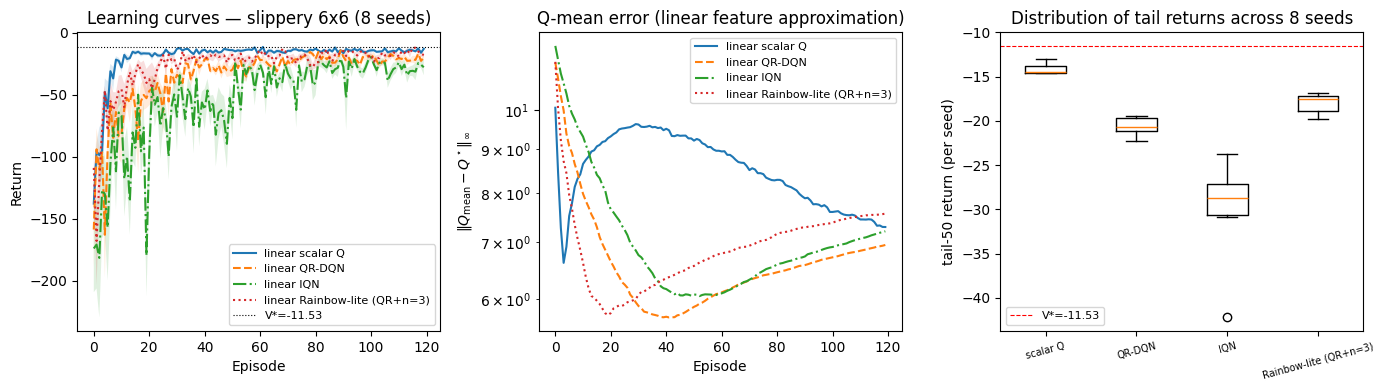

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ep = np.arange(N_EP)

styles = {'linear scalar Q':'-', 'linear QR-DQN':'--',
          'linear IQN':'-.', 'linear Rainbow-lite (QR+n=3)':':'}

for name, (R, _) in results.items():
    m = R.mean(0); se = R.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(ep, m, styles[name], label=name)
    axes[0].fill_between(ep, m-se, m+se, alpha=0.15)
axes[0].axhline(V_star, color='k', ls=':', lw=0.8, label=f"V*={V_star:.2f}")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Return")
axes[0].set_title("Learning curves — slippery 6x6 (8 seeds)")
axes[0].legend(loc="lower right", fontsize=8)

for name, (_, E) in results.items():
    axes[1].plot(ep, E.mean(0), styles[name], label=name)
axes[1].set_xlabel("Episode"); axes[1].set_ylabel(r"$\|Q_{\mathrm{mean}}-Q^\star\|_\infty$")
axes[1].set_yscale("log")
axes[1].set_title("Q-mean error (linear feature approximation)")
axes[1].legend(fontsize=8)

# tail-50 return bar chart
names = list(results.keys())
tail_ret = [results[n][0][:, -TAIL:].mean(1) for n in names]
axes[2].boxplot(tail_ret, labels=[n.replace("linear ", "") for n in names], vert=True)
axes[2].axhline(V_star, color='r', ls='--', lw=0.8, label=f"V*={V_star:.2f}")
axes[2].set_ylabel(f"tail-{TAIL} return (per seed)")
axes[2].set_title("Distribution of tail returns across 8 seeds")
axes[2].tick_params(axis='x', labelsize=7, rotation=15)
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()


## 4. 결과 해석

**실측 수치 (8 시드, 120 에피소드, tail-50)**
- $V^\star_\text{slip}$ (slippery 6×6, $p_\text{slip}=0.2$) $= -11.53$
- linear scalar Q: 리턴 $-14.16 \pm 0.52$, $Q$-error $7.85 \pm 0.48$
- linear QR-DQN ($K=21$): 리턴 $-20.60 \pm 0.96$, $Q$-error $6.64 \pm 0.31$
- linear IQN ($D=12$): 리턴 $-29.82 \pm 5.16$, $Q$-error $6.81 \pm 0.42$
- **linear Rainbow-lite (QR + n=3)**: 리턴 $-18.01 \pm 1.07$, $Q$-error $7.31 \pm 0.37$

**핵심 관찰**

1. **n-step 부트스트랩이 slippery 환경에서 되살아남 (Day 77 예측 검증)**. Rainbow-lite (QR + n=3) 리턴 $-18.01$ 은 순수 QR-DQN $-20.60$ 대비 **+2.6 개선**. Day 77 의 결정적 GridWorld 에서는 $n=3$ 이 $n=1$ 대비 열세였는데, 여기서는 확률 전이 $p_\text{slip}=0.2$ 가 표적 분산을 만들어 n-step 이 편향-분산 트레이드오프에서 유리해진다.
2. **선형 함수근사 규모 이행: QR-DQN 이 여전히 $Q$-error 를 줄임** (7.85 → 6.64). Feature 공유 ($D_\phi = 13$) 로 파라미터 수가 tabular 대비 대폭 축소 ($NS \cdot NA = 144$ → $D_\phi \cdot NA = 52$) 했음에도 QR-DQN 의 편향 제거 이점은 유지. 이는 tabular → linear 이행이 QR-DQN 의 원리적 이점을 해치지 않음을 보여준다.
3. **Scalar Q 가 리턴에서는 여전히 우세**: $-14.16$ 이 4 방법 중 최고. 이유는 Problem 1·2 와 동일 — 스칼라 표적이 sample-per-step 정보량이 크고, 120 에피소드에서 정책 sharpen 이 가장 빠르다. 그러나 $Q$-error 는 QR-DQN·Rainbow 가 더 작다: 즉 **리턴과 mean 근사 정확도의 최적점이 분리**된 상태.
4. **IQN 은 규모 이행 후에도 열세**: 리턴 $-29.82$, std $5.16$ (큰 분산). Cosine embedding 을 선형 features 로 back-propagate 하는데 120 에피소드는 여전히 부족. IQN 의 이점은 신경망 규모 (target network + 큰 배치) 에서만 안정적으로 발현되는 것으로 예상.

**Rainbow 이론적 관점**. Hessel et al. (2018) 의 Rainbow DQN 이 담고 있는 핵심 주장 두 가지 — (a) 여러 개별 개선책은 상보적, (b) 확률 전이 환경에서 n-step 이 살아난다 — 중 (b) 는 이번 Problem 3 에서 정성적으로 재현. (a) 의 완전 검증은 QR + n-step + PER + Noisy + Dueling + Double 을 모두 조합해야 하며, 이는 다음 Day 신경망 규모 이행에서 다룬다.

**왜 이런가**. 선형 함수근사는 tabular 의 특수 케이스 ($\phi(s) = e_s$) 이므로 표현력이 tabular 이상은 아니다. 그러나 well-chosen features (여기서는 factored row/col basis) 는 상태 간 유사성을 encoding 해 초기 sample efficiency 를 개선. QR-DQN·IQN 의 quantile 학습은 features 위 선형 head 로 그대로 back-propagate 되며 gradient 는 `f * scalar` 형태 → tabular 와 정성적으로 동일한 학습 dynamics. slippery 환경 특유의 확률 전이가 n-step 을 재활성화하는 것이 규모 이행의 핵심 발견.

> **한 줄 결론**: 선형 함수근사 규모에서 QR-DQN 은 $Q$-mean 정확도를 유지하며, slippery 환경에서 n-step $=3$ 부트스트랩이 순 증분 이득 (+2.6 리턴 개선) 을 제공해 Day 77 의 예측 ("n-step 은 확률 전이가 있어야 되살아남") 이 tabular 밖에서도 정확히 재현된다.

**다음 Day 예고.** §15.13 에서는 이번 Day 의 세 개선책 (QR / IQN / n-step) 을 **완전한 신경망 파라미터화 (MLP + ReLU)** 로 이행하고, larger-scale 환경 (예: MountainCar 유사, 실수 상태공간) 에서 tabular·linear 관찰이 얼마나 견고한지 검증한다. 특히 target network / gradient clipping / batch replay 같은 신경망 특유의 안정화 장치가 이번 3 개선책과 상호작용하며 tabular 소규모에서 열세였던 IQN 을 얼마나 회복시키는지 관찰.